# *Superstore Revenue & Profitability Optimization Analysis*

## **Business Problem**
Superstore wants to increase profitable revenue, but high sales do not necessarily translate into high profit. Management needs to identify where sales and profit are being generated and understand whether discounting is associated with declining profit margins, so that pricing and sales strategies can be improved.


# 1. Data Understanding & Cleaning

The first step is to understand the structure and quality of the Superstore
dataset before performing business analysis.

In [1]:
## 1. Load the dataset
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
# Load dataset
df = pd.read_csv( r"C:\Users\HP\OneDrive\Documents\DATA ANALYST-DATASET\Sample - Superstore.csv",encoding='latin1')

# Display first 5 rows
df.head()

,Row ID,Order ID,Order Date,Ship Date,Ship Mode,Customer ID,Customer Name,Segment,Country,City,...,Postal Code,Region,Product ID,Category,Sub-Category,Product Name,Sales,Quantity,Discount,Profit
0,1,CA-2016-152156,11/8/2016,11/11/2016,Second Class,CG-12520,Claire Gute,Consumer,United States,Henderson,...,42420,South,FUR-BO-10001798,Furniture,Bookcases,Bush Somerset Collection Bookcase,261.9600,2,0.00,41.9136
1,2,CA-2016-152156,11/8/2016,11/11/2016,Second Class,CG-12520,Claire Gute,Consumer,United States,Henderson,...,42420,South,FUR-CH-10000454,Furniture,Chairs,"Hon Deluxe Fabric Upholstered Stacking Chairs,...",731.9400,3,0.00,219.5820
2,3,CA-2016-138688,6/12/2016,6/16/2016,Second Class,DV-13045,Darrin Van Huff,Corporate,United States,Los Angeles,...,90036,West,OFF-LA-10000240,Office Supplies,Labels,Self-Adhesive Address Labels for Typewriters b...,14.6200,2,0.00,6.8714
3,4,US-2015-108966,10/11/2015,10/18/2015,Standard Class,SO-20335,Sean O'Donnell,Consumer,United States,Fort Lauderdale,...,33311,South,FUR-TA-10000577,Furniture,Tables,Bretford CR4500 Series Slim Rectangular Table,957.5775,5,0.45,-383.0310
4,5,US-2015-108966,10/11/2015,10/18/2015,Standard Class,SO-20335,Sean O'Donnell,Consumer,United States,Fort Lauderdale,...,33311,South,OFF-ST-10000760,Office Supplies,Storage,Eldon Fold 'N Roll Cart System,22.3680,2,0.20,2.5164


In [2]:
## 2. Check dataset size
print("Rows:", df.shape[0])
print("Columns:", df.shape[1])

Rows: 9994
Columns: 21


In [3]:
## 3. Check column names
df.columns.tolist()

['Row ID',
 'Order ID',
 'Order Date',
 'Ship Date',
 'Ship Mode',
 'Customer ID',
 'Customer Name',
 'Segment',
 'Country',
 'City',
 'State',
 'Postal Code',
 'Region',
 'Product ID',
 'Category',
 'Sub-Category',
 'Product Name',
 'Sales',
 'Quantity',
 'Discount',
 'Profit']

In [4]:
## 4. Check data types
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 9994 entries, 0 to 9993
Data columns (total 21 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   Row ID         9994 non-null   int64  
 1   Order ID       9994 non-null   object 
 2   Order Date     9994 non-null   object 
 3   Ship Date      9994 non-null   object 
 4   Ship Mode      9994 non-null   object 
 5   Customer ID    9994 non-null   object 
 6   Customer Name  9994 non-null   object 
 7   Segment        9994 non-null   object 
 8   Country        9994 non-null   object 
 9   City           9994 non-null   object 
 10  State          9994 non-null   object 
 11  Postal Code    9994 non-null   int64  
 12  Region         9994 non-null   object 
 13  Product ID     9994 non-null   object 
 14  Category       9994 non-null   object 
 15  Sub-Category   9994 non-null   object 
 16  Product Name   9994 non-null   object 
 17  Sales          9994 non-null   float64
 18  Quantity

In [5]:
## 5. Check missing values
df.isnull().sum()

Row ID           0
Order ID         0
Order Date       0
Ship Date        0
Ship Mode        0
Customer ID      0
Customer Name    0
Segment          0
Country          0
City             0
State            0
Postal Code      0
Region           0
Product ID       0
Category         0
Sub-Category     0
Product Name     0
Sales            0
Quantity         0
Discount         0
Profit           0
dtype: int64

In [6]:
## 6. Check duplicate rows
print("Duplicate rows:", df.duplicated().sum())

Duplicate rows: 0


In [7]:
## 7. Convert dates
df['Order Date'] = pd.to_datetime(df['Order Date'])
df['Ship Date'] = pd.to_datetime(df['Ship Date'])

In [8]:
df[['Order Date', 'Ship Date']].dtypes

Order Date    datetime64[ns]
Ship Date     datetime64[ns]
dtype: object

In [9]:
## 8. Check important numerical columns
df[['Sales', 'Quantity', 'Discount', 'Profit']].describe()

,Sales,Quantity,Discount,Profit
count,9994.000000,9994.000000,9994.000000,9994.000000
mean,229.858001,3.789574,0.156203,28.656896
std,623.245101,2.225110,0.206452,234.260108
min,0.444000,1.000000,0.000000,-6599.978000
25%,17.280000,2.000000,0.000000,1.728750
50%,54.490000,3.000000,0.200000,8.666500
75%,209.940000,5.000000,0.200000,29.364000
max,22638.480000,14.000000,0.800000,8399.976000


In [10]:
## 9. Final check
print("Dataset shape:", df.shape)
print("Missing values:", df.isnull().sum().sum())
print("Duplicate rows:", df.duplicated().sum())

Dataset shape: (9994, 21)
Missing values: 0
Duplicate rows: 0


# 2. Feature Engineering

To support profitability and time-based analysis, two useful features
are created: Profit Margin and Month-Year.

In [11]:
# Profit Margin
df['Profit Margin'] = (df['Profit'] / df['Sales']) * 100

# Month-Year for trend analysis
df['Month-Year'] = df['Order Date'].dt.to_period('M').dt.to_timestamp()

# Check the new columns
df[['Sales', 'Profit', 'Profit Margin', 'Month-Year']].head()

,Sales,Profit,Profit Margin,Month-Year
0,261.9600,41.9136,16.00,2016-11-01
1,731.9400,219.5820,30.00,2016-11-01
2,14.6200,6.8714,47.00,2016-06-01
3,957.5775,-383.0310,-40.00,2015-10-01
4,22.3680,2.5164,11.25,2015-10-01


# 3. Overall Business Performance

Before investigating products, categories, regions, and discounting,
we first establish the overall financial performance of Superstore.

The key metrics are Total Sales, Total Profit, Profit Margin, and
Total Orders.

In [12]:
# Overall business KPIs

total_sales = df['Sales'].sum()
total_profit = df['Profit'].sum()
profit_margin = (total_profit / total_sales) * 100
total_orders = df['Order ID'].nunique()

print(f"Total Sales: ${total_sales:,.2f}")
print(f"Total Profit: ${total_profit:,.2f}")
print(f"Profit Margin: {profit_margin:.2f}%")
print(f"Total Orders: {total_orders:,}")

Total Sales: $2,297,200.86
Total Profit: $286,397.02
Profit Margin: 12.47%
Total Orders: 5,009


In [13]:
# Monthly sales

monthly_sales = (
    df.groupby('Month-Year')['Sales']
      .sum()
      .reset_index()
)

monthly_sales.head()

,Month-Year,Sales
0,2014-01-01,14236.895
1,2014-02-01,4519.892
2,2014-03-01,55691.009
3,2014-04-01,28295.345
4,2014-05-01,23648.287


# 3. Monthly Sales Trend

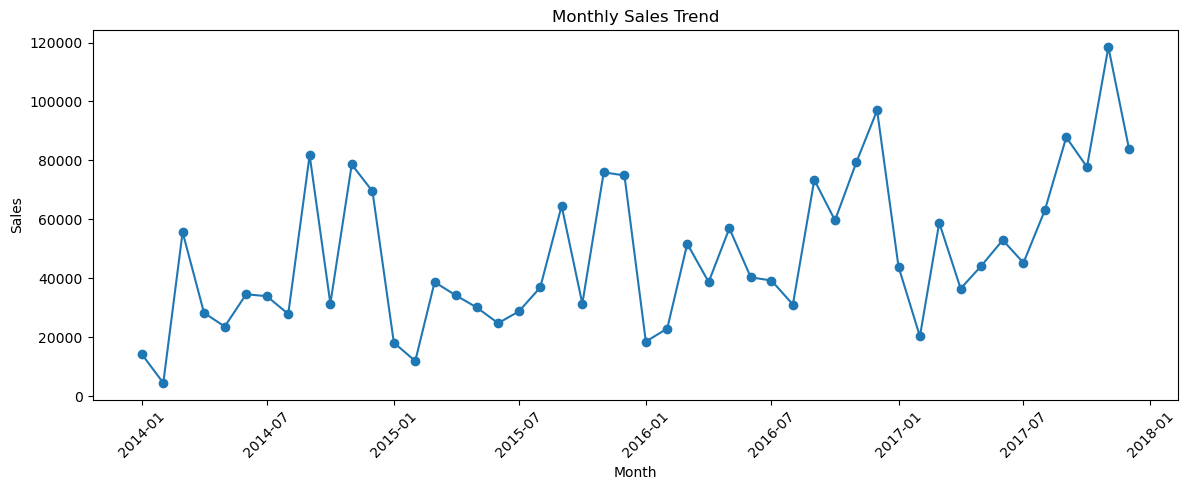

In [14]:
plt.figure(figsize=(12, 5))

plt.plot(
    monthly_sales['Month-Year'],
    monthly_sales['Sales'],
    marker='o'
)

plt.title('Monthly Sales Trend')
plt.xlabel('Month')
plt.ylabel('Sales')

plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

In [15]:
highest_month = monthly_sales.loc[
    monthly_sales['Sales'].idxmax()
]

lowest_month = monthly_sales.loc[
    monthly_sales['Sales'].idxmin()
]

print(
    f"Highest Sales Month: "
    f"{highest_month['Month-Year'].strftime('%B %Y')} "
    f"(${highest_month['Sales']:,.2f})"
)

print(
    f"Lowest Sales Month: "
    f"{lowest_month['Month-Year'].strftime('%B %Y')} "
    f"(${lowest_month['Sales']:,.2f})"
)

Highest Sales Month: November 2017 ($118,447.82)
Lowest Sales Month: February 2014 ($4,519.89)


### Business Insight
How does Superstore's revenue change over time?

Monthly sales show significant variation over time. Sales peaked in
November 2017 at USD (118,447.82), while February 2014 recorded the lowest
sales at USD (4,519.89). This indicates substantial changes in sales
performance across the business period.

# 4. Sales vs Profitability

Sales vs Profit by Category

Sales vs Profit by Region

### Sales vs Profit by Category

In [16]:
category_analysis = df.groupby('Category').agg(
    Sales=('Sales', 'sum'),
    Profit=('Profit', 'sum')
).reset_index()

category_analysis['Profit Margin'] = (
    category_analysis['Profit'] / category_analysis['Sales']
) * 100

category_analysis

,Category,Sales,Profit,Profit Margin
0,Furniture,741999.7953,18451.2728,2.486695
1,Office Supplies,719047.0320,122490.8008,17.035158
2,Technology,836154.0330,145454.9481,17.395712


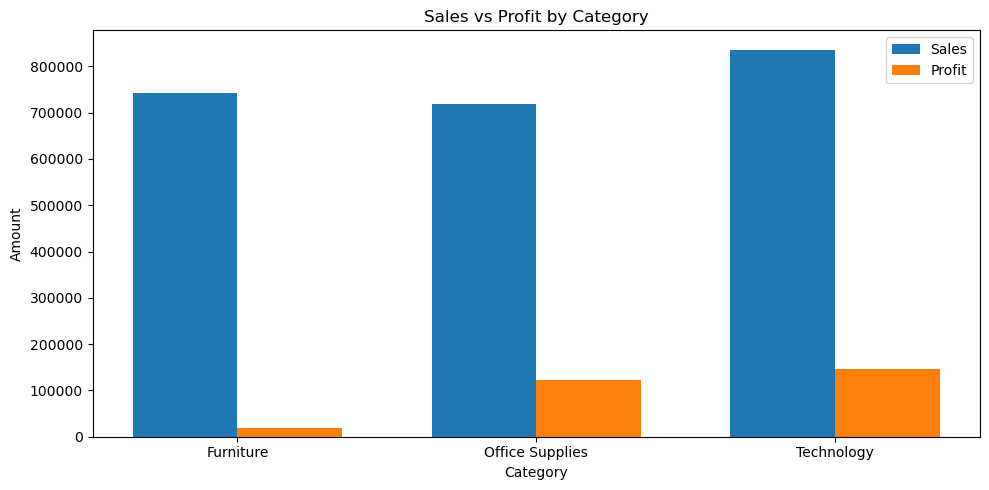

In [17]:
plt.figure(figsize=(10, 5))

x = np.arange(len(category_analysis['Category']))
width = 0.35

plt.bar(x - width/2, category_analysis['Sales'], width, label='Sales')
plt.bar(x + width/2, category_analysis['Profit'], width, label='Profit')

plt.xticks(x, category_analysis['Category'])
plt.xlabel('Category')
plt.ylabel('Amount')
plt.title('Sales vs Profit by Category')
plt.legend()

plt.tight_layout()
plt.show()

### *Business Question:*
Are high-sales categories also highly profitable?

### *Key Insight:*
Technology generates the highest sales at approximately USD (836K) and also delivers strong profitability, with approximately USD (145K) in profit. Furniture generates approximately USD (742K) in sales but only USD (18.5K) in profit, resulting in a much lower profit margin of 2.49%. This indicates that high sales do not necessarily translate into strong profitability.

### *Business Implication:*
Furniture requires further attention to pricing and discounting strategies because its substantial sales are generating relatively weak profit.

### Sales vs Profit by Region

In [18]:
region_analysis = df.groupby('Region').agg(
    Sales=('Sales', 'sum'),
    Profit=('Profit', 'sum')
).reset_index()

region_analysis['Profit Margin'] = (
    region_analysis['Profit'] / region_analysis['Sales']
) * 100

region_analysis

,Region,Sales,Profit,Profit Margin
0,Central,501239.8908,39706.3625,7.921629
1,East,678781.2400,91522.7800,13.483399
2,South,391721.9050,46749.4303,11.934342
3,West,725457.8245,108418.4489,14.944831


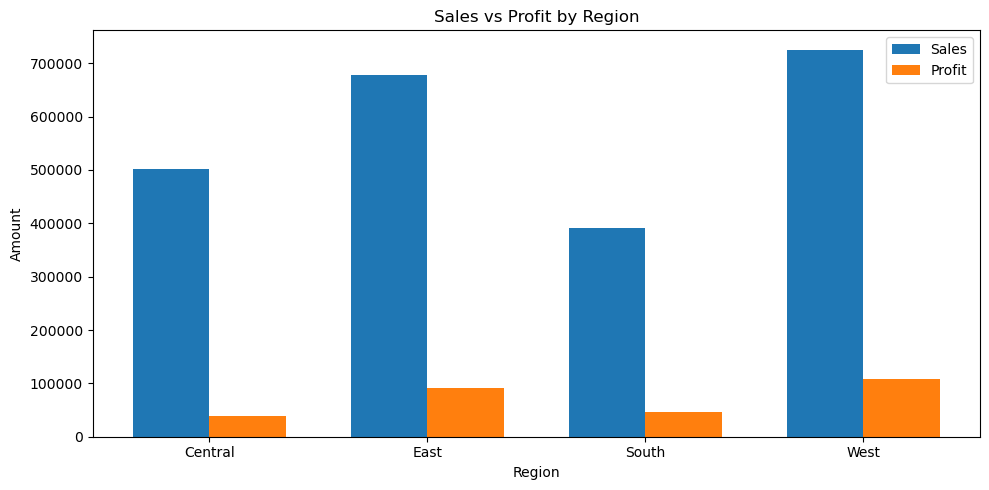

In [19]:
plt.figure(figsize=(10, 5))

x = np.arange(len(region_analysis['Region']))
width = 0.35

plt.bar(x - width/2, region_analysis['Sales'], width, label='Sales')
plt.bar(x + width/2, region_analysis['Profit'], width, label='Profit')

plt.xticks(x, region_analysis['Region'])
plt.xlabel('Region')
plt.ylabel('Amount')
plt.title('Sales vs Profit by Region')
plt.legend()

plt.tight_layout()
plt.show()

### *Business Question:*

Which regions generate strong revenue and profitability?

### *Key Insight:*

The West region is the strongest performer, generating approximately USD (725K) in sales and USD (108K) in profit with a 14.94% profit margin. In contrast, Central generates approximately USD (501K) in sales but only USD(39.7K) in profit, resulting in a much lower 7.92% margin.

### *Business Implication:*

Central's relatively weak profitability despite substantial sales suggests that the company should investigate pricing and discounting practices in this region.

## **Conclusion**

Overall, the analysis shows that revenue volume alone does not guarantee profitability. Technology and the West region demonstrate stronger conversion of sales into profit, while Furniture and Central show weaker profitability despite substantial sales. This highlights the need to examine discounting and pricing strategies, which will be investigated in the next stage of the analysis.

## **5. Discount & Pricing Analysis**

1.Discount vs Sales

2.Discount vs Profit Margin

In [20]:
df['Discount Band'] = pd.cut(
    df['Discount'],
    bins=[-0.01, 0.10, 0.20, 0.30, 0.40, 0.50, 1.00],
    labels=['0–10%', '10–20%', '20–30%', '30–40%', '40–50%', '50%+']
)

In [21]:
df['Discount Band'].value_counts().sort_index()

Discount Band
0–10%     4892
10–20%    3709
20–30%     227
30–40%     233
40–50%      77
50%+       856
Name: count, dtype: int64

### Discount vs Sales

In [22]:
## Discount vs Sales
discount_analysis = df.groupby(
    'Discount Band',
    observed=False
).agg(
    Sales=('Sales', 'sum'),
    Profit=('Profit', 'sum')
).reset_index()

discount_analysis

,Discount Band,Sales,Profit
0,0–10%,1.142278e+06,330016.7802
1,10–20%,7.921529e+05,91756.2975
2,20–30%,1.032267e+05,-10369.2774
3,30–40%,1.309112e+05,-25448.1881
4,40–50%,6.440351e+04,-22999.5392
5,50%+,6.422874e+04,-76559.0513


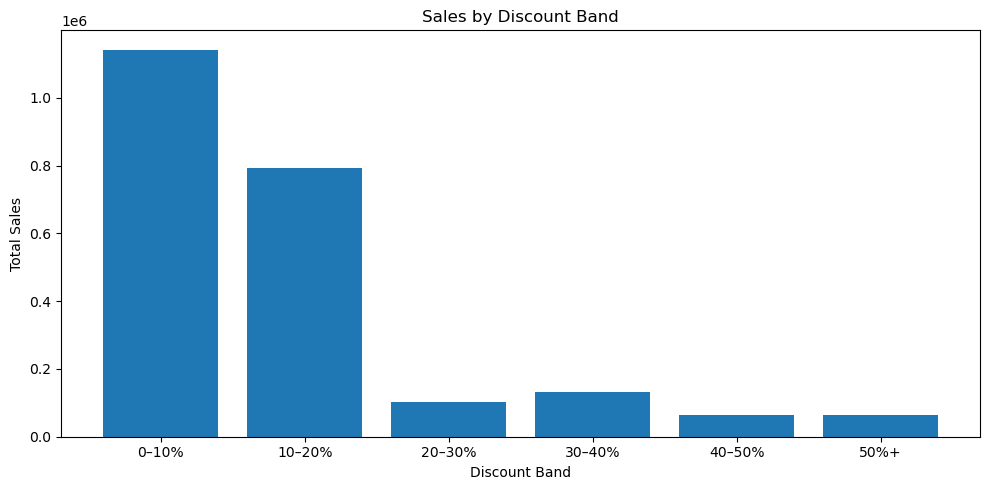

In [23]:
plt.figure(figsize=(10, 5))

plt.bar(
    discount_analysis['Discount Band'],
    discount_analysis['Sales']
)

plt.title('Sales by Discount Band')
plt.xlabel('Discount Band')
plt.ylabel('Total Sales')

plt.tight_layout()
plt.show()

### *Business question*
Do higher discounts correspond with higher sales?

### *Key Insight*
Most sales are generated at lower discount levels. The 0–10% discount band generates approximately $1.14M in sales, compared with $792K at 10–20%. Sales then fall sharply to about $103K at 20–30% and remain much lower at higher discount levels. This indicates that higher discounts do not correspond with higher sales.

### *Business Implication*
Superstore should avoid using higher discounts as a primary way to increase sales. Since the highest sales are achieved at lower discount levels, management should focus on maintaining effective discount levels while protecting profit margins.

## Discount vs Profit Margin

In [24]:
## Discount vs Profit Margin
discount_analysis['Profit Margin'] = (
    discount_analysis['Profit'] /
    discount_analysis['Sales']
) * 100

discount_analysis

,Discount Band,Sales,Profit,Profit Margin
0,0–10%,1.142278e+06,330016.7802,28.891113
1,10–20%,7.921529e+05,91756.2975,11.583155
2,20–30%,1.032267e+05,-10369.2774,-10.045155
3,30–40%,1.309112e+05,-25448.1881,-19.439269
4,40–50%,6.440351e+04,-22999.5392,-35.711622
5,50%+,6.422874e+04,-76559.0513,-119.197502


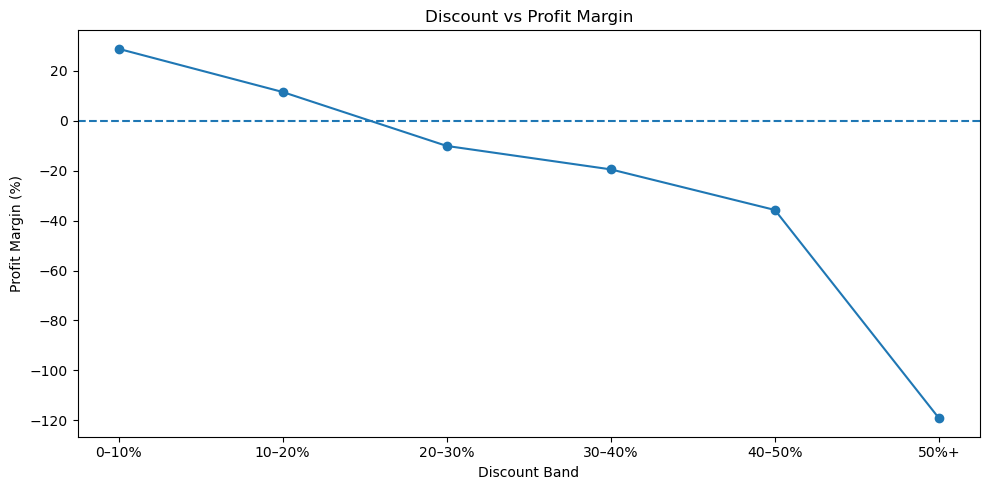

In [25]:
plt.figure(figsize=(10, 5))

plt.plot(
    discount_analysis['Discount Band'],
    discount_analysis['Profit Margin'],
    marker='o'
)

plt.axhline(0, linestyle='--')

plt.title('Discount vs Profit Margin')
plt.xlabel('Discount Band')
plt.ylabel('Profit Margin (%)')

plt.tight_layout()
plt.show()

### *Business question*

Are higher discounts associated with weaker profitability?

### *Key Insight*

Profitability declines sharply as discounts increase. The profit margin is approximately 28.9% at 0–10% discount and 11.6% at 10–20%, but becomes negative at 20–30% (-10.0%) and falls to -119.2% at 50%+ discount. This shows a strong association between higher discount levels and weaker profitability.

### *Business Implication*

Superstore should closely control higher discount levels, as deeper discounts are associated with negative profit margins. Management should prioritize discounts that support sales while protecting profitability.

In [26]:
discount_analysis

,Discount Band,Sales,Profit,Profit Margin
0,0–10%,1.142278e+06,330016.7802,28.891113
1,10–20%,7.921529e+05,91756.2975,11.583155
2,20–30%,1.032267e+05,-10369.2774,-10.045155
3,30–40%,1.309112e+05,-25448.1881,-19.439269
4,40–50%,6.440351e+04,-22999.5392,-35.711622
5,50%+,6.422874e+04,-76559.0513,-119.197502


# 6. Customer Segment

In [27]:
## Calculate Sales and Profit by Segment
segment_analysis = df.groupby('Segment').agg(
    Sales=('Sales', 'sum'),
    Profit=('Profit', 'sum')
).reset_index()

segment_analysis['Profit Margin'] = (
    segment_analysis['Profit'] /
    segment_analysis['Sales']
) * 100

segment_analysis

,Segment,Sales,Profit,Profit Margin
0,Consumer,1.161401e+06,134119.2092,11.548050
1,Corporate,7.061464e+05,91979.1340,13.025506
2,Home Office,4.296531e+05,60298.6785,14.034269


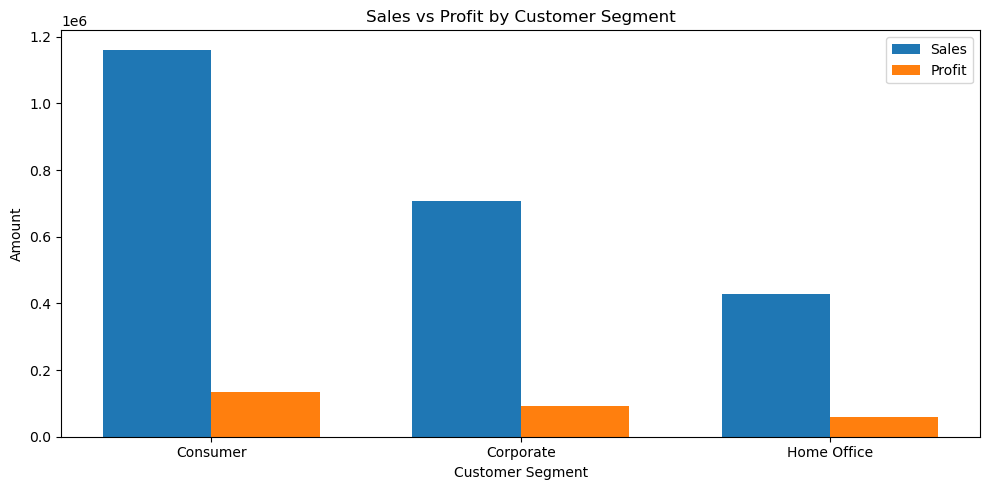

In [28]:
x = np.arange(len(segment_analysis))
width = 0.35

plt.figure(figsize=(10, 5))

plt.bar(
    x - width/2,
    segment_analysis['Sales'],
    width,
    label='Sales'
)

plt.bar(
    x + width/2,
    segment_analysis['Profit'],
    width,
    label='Profit'
)

plt.xticks(x, segment_analysis['Segment'])

plt.title('Sales vs Profit by Customer Segment')
plt.xlabel('Customer Segment')
plt.ylabel('Amount')
plt.legend()

plt.tight_layout()
plt.show()

### *Business Question*

Which customer segment generates the most valuable revenue?

### *Key Insight:*

Consumer generates the highest sales USD (1.16M) and profit USD (134.1K), making it the largest contributor to overall profitability. However, its 11.55% profit margin is lower than Corporate (13.03%) and Home Office (14.03%). Home Office, despite having the lowest sales, achieves the highest margin, indicating stronger profitability efficiency.

### *Business Implication:*

Management should protect the Consumer segment's strong revenue contribution while identifying opportunities to improve its profit margin. The higher-margin Home Office segment also represents a potential opportunity for profitable growth.

# 7. Business Recommendations

### 1. Furniture has strong sales but weak profitability

**Finding:** Furniture generates about USD (742K) in sales, but only USD (18.5K) in profit, giving it a low 2.49% profit margin.

**Business Impact:** Furniture brings in a lot of revenue, but very little of that revenue becomes profit.

**Recommendation:** Review Furniture pricing, discounts, and costs to find ways to improve its profit margin without reducing sales significantly.

---

### 2. West is the strongest region for profitable revenue


**Finding:** The West region generates the highest sales USD (725.46K), profit USD (108.42K), and profit margin (14.94%).

**Business Impact:** West is currently the strongest region because it combines high revenue with strong profitability.

**Recommendation:** Identify what is working well in the West, such as pricing or sales practices, and consider applying similar strategies in weaker regions.

---

### 3. Higher discounts are associated with weaker profitability

**Finding:** Profit margin falls as discount levels increase. It is 28.89% at 0–10% discount but falls to -119.20% at 50%+ discount.

**Business Impact:** Heavy discounting can result in very low or even negative profitability.

**Recommendation:** Review high-discount transactions and set reasonable discount limits so that discounts increase sales without damaging profitability.

---

### 4. Consumer generates the most total profit, while Home Office has the highest margin
Finding: Consumer generates the highest sales USD (1.16M) and total profit USD (134.12K). However, Home Office has the highest profit margin (14.03%).

Business Impact: Consumer contributes the most total profit because of its large sales volume, while Home Office earns a higher return from each dollar of sales.

Recommendation: Continue focusing on the Consumer segment for profitable revenue while studying what makes Home Office more efficient and considering whether those practices can be applied to other segments.